# IID Mutations for Joe

In [1]:
!TZ=America/Los_Angeles date

Fri Aug 31 19:29:29 PDT 2018


In [2]:
%autosave 30
%matplotlib notebook
%run ../Code/bs.py

Autosaving every 30 seconds


## Some analysis [Added 08-31]

With a large number $L$ of loci at which mutations occur independently with probability $1/L,$ the probability that no mutation occurs at any of the loci in an offspring is 

\begin{equation*}
(1 - 1/L)^L \approx e^{-1} \approx .368.
\end{equation*}

Given that an occurrence of mutation possibly has zero effect on the fitness of the offspring, the probability $e^{-1}$ that no mutation occurs at any locus is a lower bound on the probability that an offspring is identical in type (discrete level of fitness) to its parent. For the cases that we consider, the probability of multiple, non-neutral mutations with effects summing to zero is small. So the probablity that an offspring is identical in type (discrete level of fitness) to its parent is slightly greater than the probability that all mutations occurring in the offspring have zero effect on fitness,

\begin{align*}
   \sum_{n=0}^L P(X = n) \cdot p_0^n,
\end{align*}

where $p_0$ is the probability that a mutation occurring at a locus has zero effect on the fitness of the offspring, and $X$ is a random variable with values following the binomial distribution $\text{Binom}(L, 1/L).$ The following Python function corresponds closely to the expression displayed above.

In [3]:
def zero_bound(p_0, L=2**14):
    pmf = stats.binom(L, 1/L).pmf    # probability mass function of binomial distribution
    n = np.arange(L + 1)             # array 0, 1, ..., L
    return np.sum(pmf(n) * p_0 ** n) # inner product of binomial PMF and powers of p_0

We verify momentarily that the function `zero_bound` gives a close approximation (from below) of the probability that the offspring is identical in type to its parent when i.i.d. mutation effects at $L$ loci are additive.

## Compare single mutation effect to additive i.i.d. mutation effects

In [4]:
%run -i ../Code/multiprecision_gamma.py
%run -i ../Code/gamma.py

**Define distributions for 501 types and 50001 types.**

In [5]:
def define_distributions(n_types):
    factors = Factors(n_types)
    one_mutation = WeightedDoubleGamma(factors)
    iid_mutations = WeightedDoubleGamma(factors)
    iid_mutations.iid_effects(number_of_mutations=1, log_number_of_loci=14)
    return one_mutation, iid_mutations

d500 = define_distributions(501)    # As in Section 5.4
d50k = define_distributions(50001)  # Increase number of types by factor of 100

**Plot distributions for 501 types**

The second plot is the same as the first, except for the limits on the vertical scale.

<IPython.core.display.Javascript object>


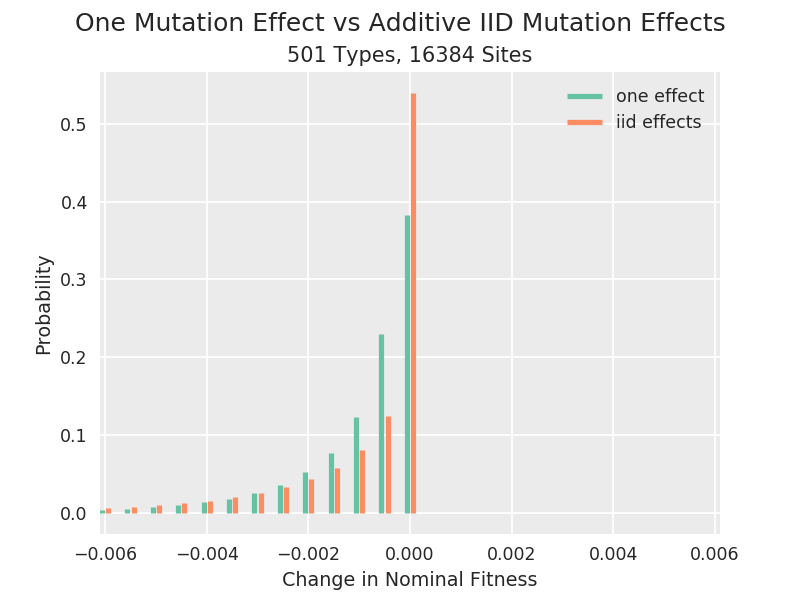

<IPython.core.display.Javascript object>


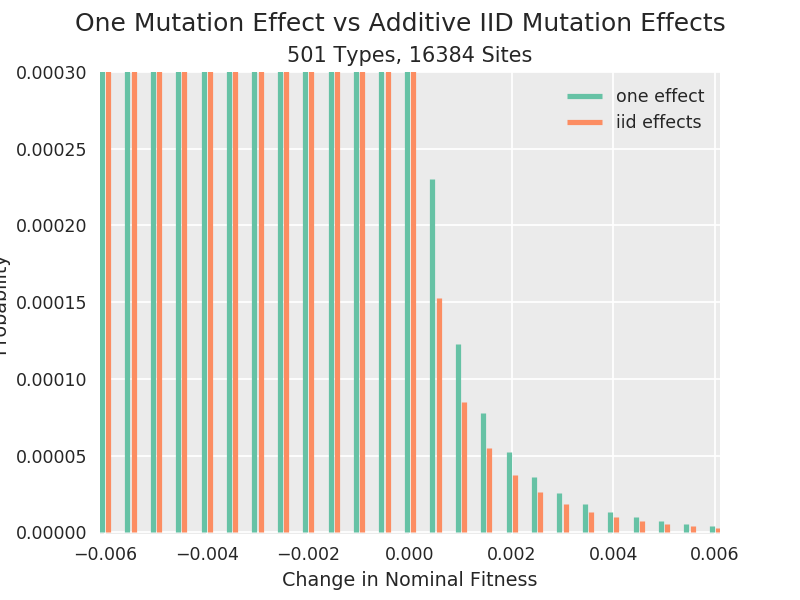

Probability of zero effect with one mutation  : 0.38292492254802624
Probability of zero effect with iid mutations : 0.539562058545165
   ... slightly exceeds calculated lower bound: 0.5395139171257591


In [6]:
def plot_gamma(distributions, xlim, ylim=None):
    one_mutation, iid_mutations = distributions
    fig, ax = plt.subplots()
    v = one_mutation.vlines(ax, x_offset=-xlim/100, label="one effect")
    v.set_color(sns.color_palette()[0])
    v = iid_mutations.vlines(ax, x_offset=xlim/100, label="iid effects")
    v.set_color(sns.color_palette()[1])
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(ylim)
    fig.suptitle('One Mutation Effect vs Additive IID Mutation Effects')
    ax.set_title('{0} Types, {1} Sites'.format(len(one_mutation) // 2 + 1, 2**iid_mutations.log_number_of_loci))
    ax.legend(loc='best')
    return fig, ax

fig, ax = plot_gamma(d500, xlim=0.0061)
fig, ax = plot_gamma(d500, xlim=0.0061, ylim=(-0.000001, 0.0003))

print('Probability of zero effect with one mutation  :', max(d500[0]))
print('Probability of zero effect with iid mutations :', max(d500[1]))
print('   ... slightly exceeds calculated lower bound:', zero_bound(max(d500[0])))

**Plot distributions for 50001 types**

The second plot is the same as the first, except for the limits on the vertical scale.

<IPython.core.display.Javascript object>


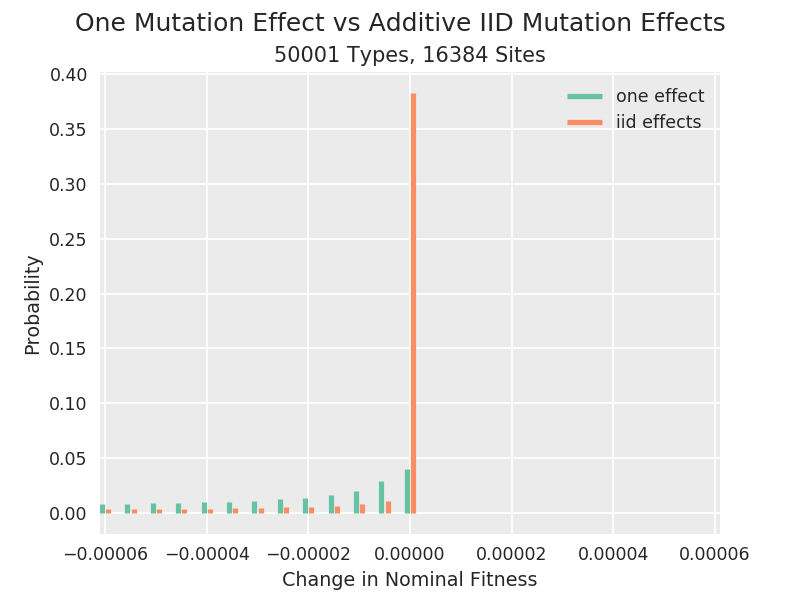

<IPython.core.display.Javascript object>


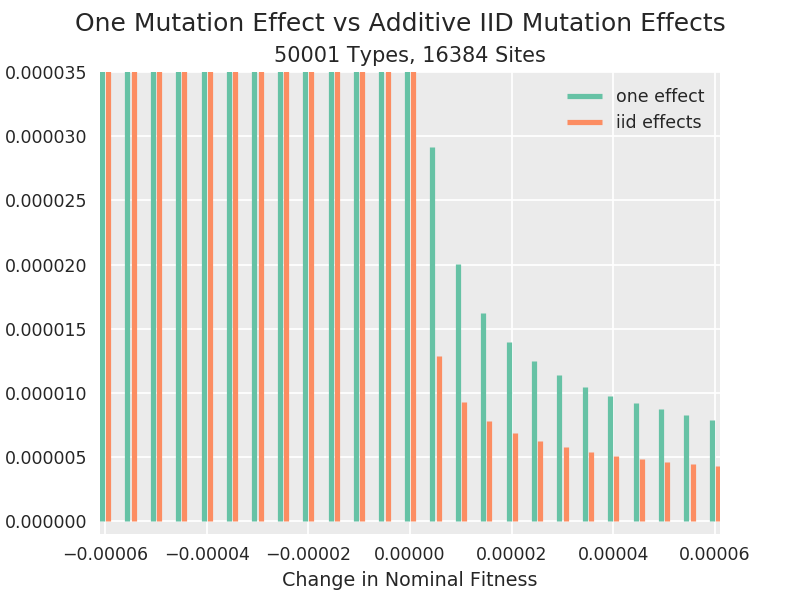

Probability of zero effect with one mutation  : 0.039877611676744924
Probability of zero effect with iid mutations : 0.3828371932389378
   ... slightly exceeds calculated lower bound: 0.3828352566650073


In [7]:
fig, ax = plot_gamma(d50k, xlim=0.000061)
fig, ax = plot_gamma(d50k, xlim=0.000061, ylim=(-0.000001, 0.000035))
print('Probability of zero effect with one mutation  :', max(d50k[0]))
print('Probability of zero effect with iid mutations :', max(d50k[1]))
print('   ... slightly exceeds calculated lower bound:', zero_bound(max(d50k[0])))